In [10]:
## leetcode 121. Best Time to Buy and Sell Stock
## first try
def max_profit_brute(prices):
    max_so_far = [0]

    for price1 in range(len(prices)):
        for price2 in range(price1 + 1,len(prices)):
            if prices[price2] - prices[price1] > 0:
                max_so_far.append(prices[price2] - prices[price1])

    return max(max_so_far)


print(max_profit_brute([7, 1, 5, 3, 6, 4]))  # 5
print(max_profit_brute([7, 6, 4, 3, 1])) 

5
0


In [12]:
## Second try
def max_profit(prices):
    if len(prices) < 2:
        return 0

    min_price = prices[0]
    max_profit = 0

    for i in range(1, len(prices)):
        price = prices[i]

        # 如果今天卖出，最多赚多少？
        profit_today = price - min_price

        # 更新截至今天的最大利润
        max_profit = max(max_profit, profit_today)

        # 更新最低价格，供后面的日期使用
        min_price = min(min_price,price)

    return max_profit

print(max_profit([7, 1, 5, 3, 6, 4]))  # 5
print(max_profit([7, 6, 4, 3, 1]))     # 0
print(max_profit([2, 4, 1]))           # 2

5
0
2


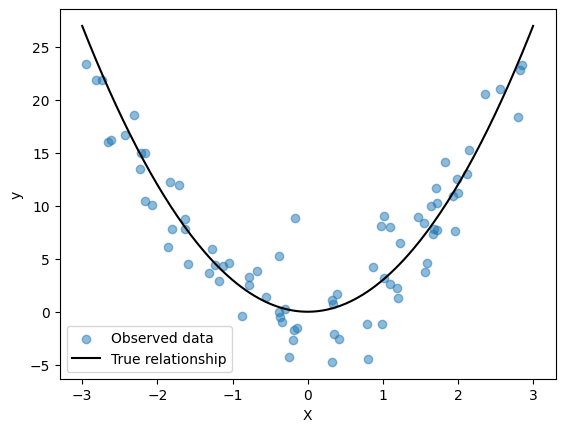

In [17]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

X = rng.uniform(-3, 3, size=(80, 1))
y = 3 * X[:, 0]**2 + rng.normal(0, 3, size=80)

x_grid = np.linspace(-3, 3, 200)

plt.scatter(X[:, 0], y, alpha=0.5, label="Observed data")
plt.plot(x_grid, 3 * x_grid**2, color="black", label="True relationship")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [18]:
from sklearn.model_selection import train_test_split

# 20% test
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# remaining 80% dev, split into 75% train and 25% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_dev, y_dev,
    test_size=0.25,
    random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (48, 1) (48,)
Validation: (16, 1) (16,)
Test: (16, 1) (16,)


In [22]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

results = []
models = {}

for degree in [1, 2, 15]:
    # 把“生成多项式特征”和“回归”组合起来
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )

    # 只用训练集拟合
    model.fit(X_train, y_train)

    # 同一个已拟合模型，分别预测训练集和验证集
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    train_mse = mean_squared_error(y_train, y_train_pred)
    val_mse = mean_squared_error(y_val, y_val_pred)

    results.append({
        "degree": degree,
        "train_mse": train_mse,
        "val_mse": val_mse
    })

    # 保存模型，后面用来画拟合曲线
    models[degree] = model
    
print(results)
print(models)
results_df = pd.DataFrame(results)
print(results_df.round(3))

[{'degree': 1, 'train_mse': 54.68341931547291, 'val_mse': 47.09795058582865}, {'degree': 2, 'train_mse': 7.341966727619753, 'val_mse': 8.798665891563893}, {'degree': 15, 'train_mse': 6.37113038216043, 'val_mse': 8.362820777052288}]
{1: Pipeline(steps=[('polynomialfeatures',
                 PolynomialFeatures(degree=1, include_bias=False)),
                ('linearregression', LinearRegression())]), 2: Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(include_bias=False)),
                ('linearregression', LinearRegression())]), 15: Pipeline(steps=[('polynomialfeatures',
                 PolynomialFeatures(degree=15, include_bias=False)),
                ('linearregression', LinearRegression())])}
   degree  train_mse  val_mse
0       1     54.683   47.098
1       2      7.342    8.799
2      15      6.371    8.363


/Users/kathyxu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/kathyxu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/kathyxu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


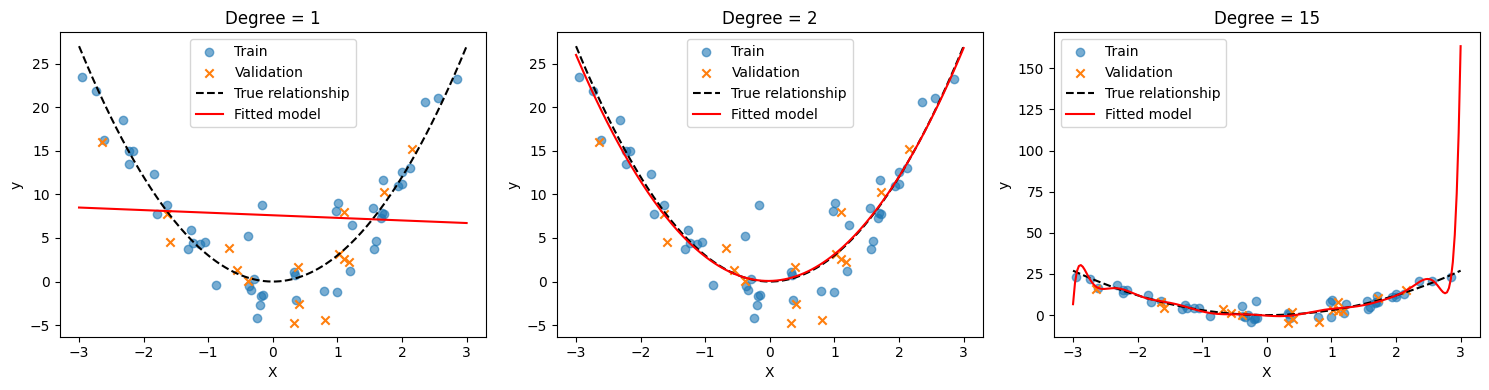

In [23]:
# sklearn 的输入需要是二维：(样本数, 特征数)
X_plot = x_grid.reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, degree in zip(axes, [1, 2, 15]):
    # 使用之前保存的模型，不重新训练
    y_plot = models[degree].predict(X_plot)

    ax.scatter(
        X_train[:, 0], y_train,
        alpha=0.6, label="Train"
    )
    ax.scatter(
        X_val[:, 0], y_val,
        marker="x", label="Validation"
    )

    ax.plot(
        x_grid, 3 * x_grid**2,
        color="black", linestyle="--", label="True relationship"
    )
    ax.plot(
        x_grid, y_plot,
        color="red", label="Fitted model"
    )

    ax.set_title(f"Degree = {degree}")
    ax.set_xlabel("X")
    ax.set_ylabel("y")
    ax.legend()

plt.tight_layout()
plt.show()

In [26]:
model = models[2]
y_val_pred = model.predict(X_val)
val_mse =  mean_squared_error(y_val, y_val_pred)
print(f"Validation MSE for degree 2: {val_mse:.3f}")

Validation MSE for degree 2: 8.799


### Bias–Variance Decomposition

固定输入 x，对不同训练数据和独立的新观测取平均：

$$
\text{Expected squared prediction error}
=
\text{Bias}^2
+
\text{Variance}
+
\text{Noise variance}
$$

- **Bias**：多次训练后的平均预测与真实条件均值的差。
- **Variance**：换训练数据、重新拟合后，预测的变化程度。
- **Noise variance**：新观测自身的随机噪声带来的不可约误差。

例如：Bias = -4，Variance = 0，Noise variance = 9，
则期望平方预测误差为 16 + 0 + 9 = 25。

注意：这是期望误差的分解；有限验证集上的 MSE 会有抽样波动。

In [27]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    models[2], X_dev, y_dev,
    cv=4,
    scoring="neg_mean_squared_error"
)

In [28]:
fold_mse = -scores
print(fold_mse)
print(fold_mse.mean())

[14.16627756  5.18604287  5.72999175  7.1070032 ]
8.047328845609606


In [30]:
scores_15 = cross_val_score(
    models[15], X_dev, y_dev,
    cv=4,
    scoring="neg_mean_squared_error"
)
fold_mse_15 = -scores_15
print(fold_mse_15)
print(fold_mse_15.mean())

[5556.94761135    7.44593987   90.06073079   44.48805754]
1424.735584889548


In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

ridge_model = make_pipeline(
    PolynomialFeatures(degree=15, include_bias=False),
    StandardScaler(),#standardization 
    Ridge(alpha=1.0)#ridge
)

In [46]:
ridge_scores = cross_val_score(
    ridge_model, X_dev, y_dev,
    cv=4,
    scoring = "neg_mean_squared_error"
)

ridge_fold_mse = - ridge_scores
print(ridge_fold_mse)
print(ridge_fold_mse.mean())

[14.64126741  4.73267624  7.15818015  6.59518364]
8.28182686301907


/Users/kathyxu/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kathyxu/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kathyxu/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kathyxu/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kathyxu/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kathyxu/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/kathyxu/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extma

In [47]:
final_model = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression()
)
final_model.fit(X_dev, y_dev)

test_pred = final_model.predict(X_test)
test_mse = mean_squared_error(y_test, test_pred)
print(test_mse)

7.413973255965521
